In [1]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_and_smooth_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Returns two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_original"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list

def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB


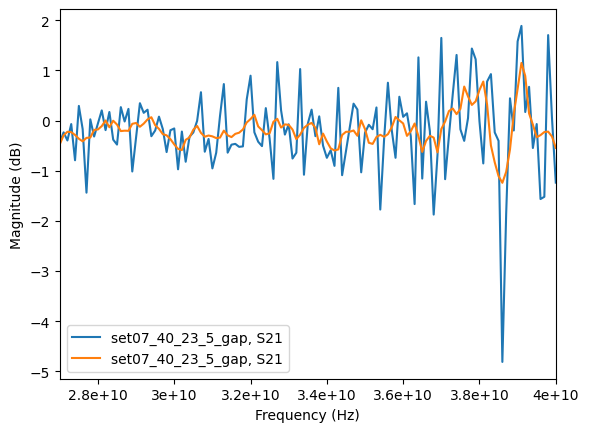

In [2]:
import matplotlib.pyplot as plt
set_07_original, set_07_smoothed = load_and_smooth_directory(r'meas data\sample1_quarter\set07', window=11, poly=3)
# plt.figure()
# plt.title('S11 Magnitude (dB)')
# for ntwk in set_07_smoothed:
#     ntwk.plot_s_db(m=1, n=0, show_legend=False)

# # plt.legend()
# plt.show()
set_07_original[9].plot_s_db(m=1, n=0)
set_07_smoothed[9].plot_s_db(m=1, n=0)

In [11]:
import pprint
results = []
for ntwk in set07_smoothed:
    results.append((ntwk.name, worst_return_loss(ntwk)))

results_sorted = sorted(results, key=lambda x: x[1])
pprint.pprint(results_sorted)

[('set07_40_21_5_gap', np.float64(-15.501699630673633)),
 ('set07_40_16_5_gap', np.float64(-13.734776942610505)),
 ('set07_40_22_5_gap', np.float64(-13.28242308070595)),
 ('set07_40_18_5_gap', np.float64(-12.862977177986219)),
 ('set07_40_14_5_gap', np.float64(-12.845901377517796)),
 ('set07_40_23_5_gap', np.float64(-11.467599488114011)),
 ('set04_40_22_5_gap_re', np.float64(-11.37040909444178)),
 ('set07_40_25_5_gap', np.float64(-11.130404901543242)),
 ('set07_40_17_5_gap', np.float64(-10.480417170742086)),
 ('set07_40_19_5_gap', np.float64(-8.56968327120927)),
 ('set07_40_20_5_gap', np.float64(-7.946356098987355))]


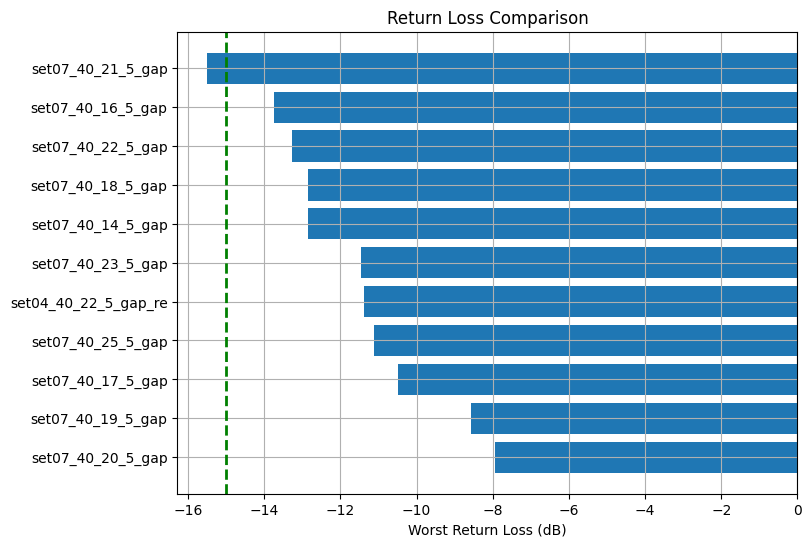

In [12]:
names = []
values = []

for ntwk in set07_smoothed:
    names.append(ntwk.name)
    values.append(worst_return_loss(ntwk))

# Combine and sort (descending)
sorted_data = sorted(zip(names, values),
                     key=lambda x: x[1],
                     reverse=True)

# Unzip back
names_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(8,6))
plt.barh(names_sorted, values_sorted)

plt.axvline(x=-15, color='g', linestyle='--', linewidth=2)
plt.grid()
plt.xlabel("Worst Return Loss (dB)")
plt.title("Return Loss Comparison")

# plt.gca().invert_yaxis()   # optional: best at bottom
plt.show()

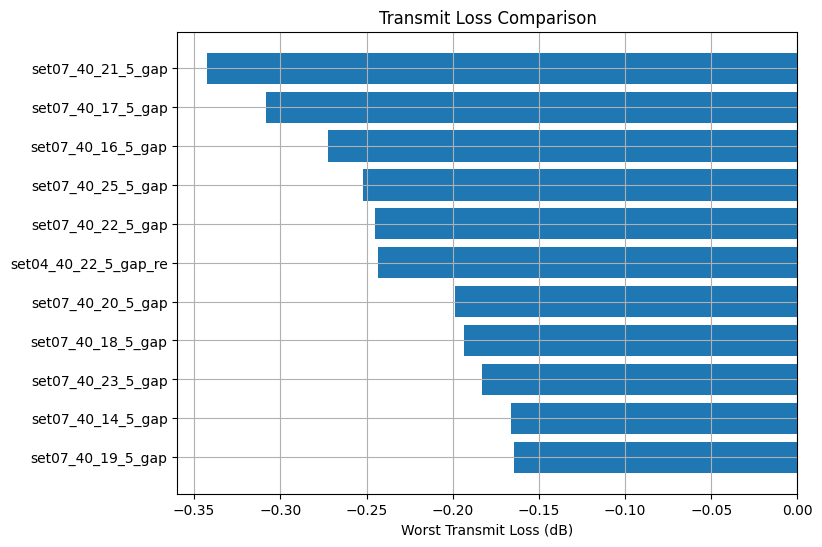

In [17]:
names = []
values = []

for ntwk in set07_smoothed:
    names.append(ntwk.name)
    values.append(avg_transmit_loss(ntwk))

# Combine and sort (descending)
sorted_data = sorted(zip(names, values),
                     key=lambda x: x[1],
                     reverse=True)

# Unzip back
names_sorted, values_sorted = zip(*sorted_data)
plt.figure(figsize=(8,6))
plt.barh(names_sorted, values_sorted)
# plt.axvline(x=-15, color='g', linestyle='--', linewidth=2)
plt.grid()
plt.xlabel("Worst Transmit Loss (dB)")
plt.title("Transmit Loss Comparison")

# plt.gca().invert_yaxis()   # optional: best at bottom
plt.show()

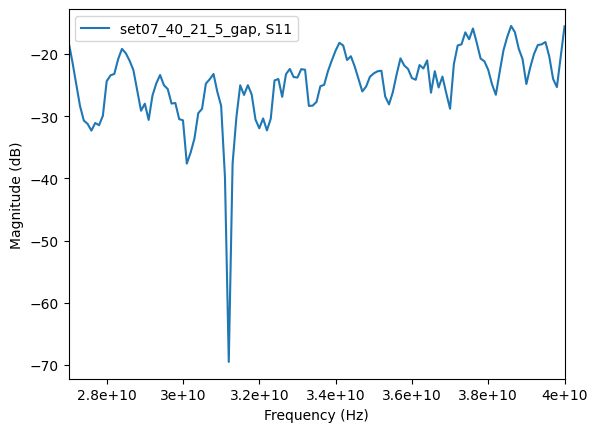

In [118]:
set_07_smoothed[7].plot_s_db(m=0, n=0)